In [171]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import sqlite3

In [15]:
#Load cell counts file for analysis
cell_counts = pd.read_csv("cell-count.csv")

In [57]:
#Part 2

#Create summary table for cell frequency
cell_freq = pd.DataFrame(columns = ["sample","total_count","population","count","percentage"])
cell_types = ["b_cell","cd8_t_cell","cd4_t_cell","nk_cell","monocyte"]

#Calculate cell relative frequency in percentage (%) for each sample and population
for i in range(len(cell_counts)):
    sample = cell_counts.loc[i,"sample"]
    total_count = cell_counts.loc[i, cell_types].sum()
    for population in cell_types:
        cell_freq.loc[len(cell_freq)] = {
            "sample": sample,
            "total_count": total_count,
            "population": population,
            "count": cell_counts[population][i],
            "percentage": (cell_counts[population][i]/total_count)*100
        }

In [58]:
#Display summary table of cell frequencies
cell_freq

,sample,total_count,population,count,percentage
0,sample00000,93214,b_cell,10908,11.702105
1,sample00000,93214,cd8_t_cell,24440,26.219237
2,sample00000,93214,cd4_t_cell,20491,21.982749
3,sample00000,93214,nk_cell,13864,14.873302
4,sample00000,93214,monocyte,23511,25.222606
...,...,...,...,...,...
52495,sample10499,92418,b_cell,9258,10.017529
52496,sample10499,92418,cd8_t_cell,29100,31.487373
52497,sample10499,92418,cd4_t_cell,26769,28.965137
52498,sample10499,92418,nk_cell,12895,13.952910


In [61]:
#Part 3

#Initialize lists of cell frequencies for responders vs. non-responders
b_cell_percentages = {"yes":[],"no":[]}
cd8_t_cell_percentages = {"yes":[],"no":[]}
cd4_t_cell_percentages = {"yes":[],"no":[]}
nk_cell_percentages = {"yes":[],"no":[]}
monocyte_percentages = {"yes":[],"no":[]}

#Get cell frequencies for responders vs. non-responders from previous cell frequency summary table and store in lists for plotting
for i in range(len(cell_counts)):
    if cell_counts.loc[i,"condition"] == "melanoma" and cell_counts.loc[i,"treatment"] == "miraclib" and cell_counts.loc[i,"sample_type"] == "PBMC":
        sample = cell_counts.loc[i,"sample"]
        indices = cell_freq.loc[cell_freq["sample"] == sample].index
        response = cell_counts.loc[i,"response"]
        if response == "yes":
            b_cell_percentages["yes"].append(cell_freq.loc[indices[0],"percentage"])
            cd8_t_cell_percentages["yes"].append(cell_freq.loc[indices[1],"percentage"])
            cd4_t_cell_percentages["yes"].append(cell_freq.loc[indices[2],"percentage"])
            nk_cell_percentages["yes"].append(cell_freq.loc[indices[3],"percentage"])
            monocyte_percentages["yes"].append(cell_freq.loc[indices[4],"percentage"])
        elif response == "no":
            b_cell_percentages["no"].append(cell_freq.loc[indices[0],"percentage"])
            cd8_t_cell_percentages["no"].append(cell_freq.loc[indices[1],"percentage"])
            cd4_t_cell_percentages["no"].append(cell_freq.loc[indices[2],"percentage"])
            nk_cell_percentages["no"].append(cell_freq.loc[indices[3],"percentage"])
            monocyte_percentages["no"].append(cell_freq.loc[indices[4],"percentage"])

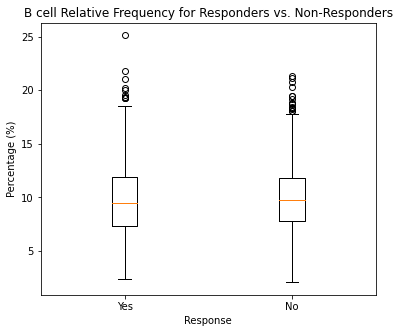

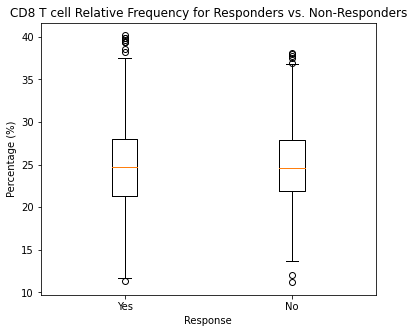

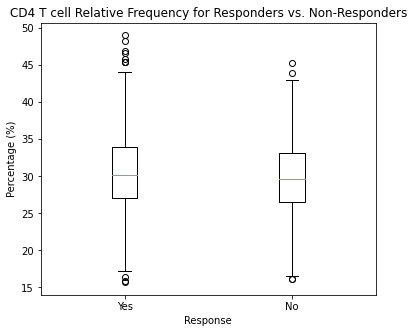

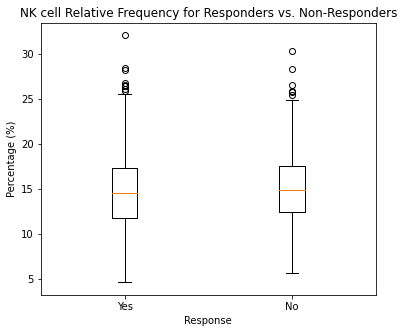

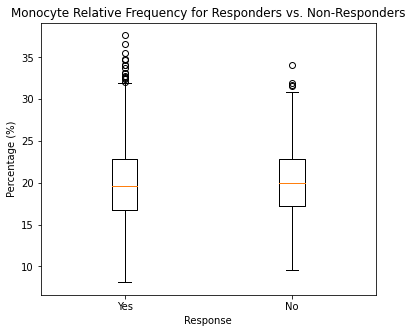

In [167]:
#Put cell frequency dictionaries together
cell_percentages = {
    "B cell": b_cell_percentages,
    "CD8 T cell": cd8_t_cell_percentages,
    "CD4 T cell": cd4_t_cell_percentages,
    "NK cell": nk_cell_percentages,
    "Monocyte": monocyte_percentages
}

#Make boxplots of cell relative frequencies for responders vs. non-responders for each cell population
for population, percentages in cell_percentages.items():
    plt.figure(figsize=(6, 5))

    plt.boxplot(
        [percentages["yes"], percentages["no"]],
        tick_labels=["Yes", "No"]
    )

    plt.title(f"{population} Relative Frequency for Responders vs. Non-Responders")
    plt.xlabel("Response")
    plt.ylabel("Percentage (%)")

    plt.show()

In [72]:
sig_populations = []

#Determine statistical significance of differences in cell frequencies between responders vs. non-responders for each cell population
for population, percentages in cell_percentages.items():
    statistic, p_value = mannwhitneyu(
        percentages["yes"],
        percentages["no"],
        alternative="two-sided"
    )
    
    if p_value < 0.05:
        sig_populations.append(population)

#Report cell populations that show significant differences 
print(
    "Cell populations with significant difference in relative frequencies "
    "between responders and non-responders:",
    ", ".join(sig_populations)
)           

Cell populations with significant difference in relative frequencies between responders and non-responders: CD4 T cell


In [162]:
#Part 4

#Connect to database from part 1 (should be loaded with load_data.py)
conn = sqlite3.connect("cell_counts.db")
cursor = conn.cursor()

#Filter data accordingly using database and get number of samples for each project
cursor.execute("""
    SELECT subjects.project, COUNT(*)
    FROM samples
    JOIN subjects
        ON samples.subject = subjects.subject
    WHERE subjects.condition = 'melanoma'
      AND samples.sample_type = 'PBMC'
      AND subjects.treatment = 'miraclib'
      AND samples.time_from_treatment_start = 0
    GROUP BY subjects.project
""")

project_counts = cursor.fetchall()

#Print results
print("Number of samples from each project:")
for project, count in project_counts:
    print(f"{project}: {count} samples")


Number of samples from each project:
prj1: 384 samples
prj3: 272 samples


In [163]:
#Filter data accordingly using database and get number of subjects who are responders/non-responders
cursor.execute("""
    SELECT subjects.response, COUNT(*)
    FROM samples
    JOIN subjects
        ON samples.subject = subjects.subject
    WHERE subjects.condition = 'melanoma'
      AND samples.sample_type = 'PBMC'
      AND subjects.treatment = 'miraclib'
      AND samples.time_from_treatment_start = 0
    GROUP BY subjects.response
    ORDER BY subjects.response DESC
""")

response_counts = cursor.fetchall()

#Print results
print("Number of subjects who were responders/non-responders:")
for response, count in response_counts:
    if response == "yes":
        label = "Responders"
    elif response == "no":
        label = "Non-responders"

    print(f"{label}: {count} subjects")

Number of subjects who were responders/non-responders:
Responders: 331 subjects
Non-responders: 325 subjects


In [164]:
#Filter data accordingly using database and get number of subjects who are males/females
cursor.execute("""
    SELECT subjects.sex, COUNT(*)
    FROM samples
    JOIN subjects
        ON samples.subject = subjects.subject
    WHERE subjects.condition = 'melanoma'
      AND samples.sample_type = 'PBMC'
      AND subjects.treatment = 'miraclib'
      AND samples.time_from_treatment_start = 0
    GROUP BY subjects.sex
    ORDER BY subjects.sex DESC
""")

sex_counts = cursor.fetchall()

#Print results
print("Number of subjects who were male/female:")
for sex, count in sex_counts:
    if sex == "M":
        label = "Males"
    elif sex == "F":
        label = "Females"

    print(f"{label}: {count} subjects")
    
conn.close()

Number of subjects who were male/female:
Males: 344 subjects
Females: 312 subjects


In [121]:
#Supplemental Question

#Calculate average number of B cells at time=0 for Melanoma males of all sample and treatment types
melanoma_males = cell_counts[
    (cell_counts["condition"] == "melanoma") & 
    (cell_counts["sex"] == "M") & 
    (cell_counts["response"] == "yes") &
    (cell_counts["time_from_treatment_start"] == 0)
]

print(f"Average number of B cells: {melanoma_males['b_cell'].mean():.2f}")

Average number of B cells: 10206.15
